In [1]:
import pyro
import pyro.distributions as dist
import torch
import torch.nn.functional as F
from pyro.infer import SVI, Trace_ELBO
from pyro.optim import Adam
from pyro import poutine
from pyro.distributions import constraints
from pyro.infer.autoguide import AutoDiagonalNormal
from pyro.infer import config_enumerate
import tqdm
import numpy as np
import seaborn
import matplotlib.pyplot as plt
import scvi
import scanpy as sc
import anndata
import pandas as pd
import scipy
import matplotlib.pyplot as plt

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

if torch.cuda.is_available():
    print("GPU is available")
    print("Number of GPUs:", torch.cuda.device_count())
    print("GPU Name:", torch.cuda.get_device_name(0))
else:
    print("GPU is not available")

import antipode

GPU is available
Number of GPUs: 1
GPU Name: NVIDIA TITAN X (Pascal)


In [2]:
! nvidia-smi

Sat Nov 16 23:00:30 2024       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 555.42.06              Driver Version: 555.42.06      CUDA Version: 12.5     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA TITAN X (Pascal)        On  |   00000000:83:00.0 Off |                  N/A |
| 39%   55C    P8             13W /  250W |     293MiB /  12288MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


In [3]:
# Set random seed for reproducibility
pyro.set_rng_seed(0)

# Define constants
n_latent = 6
n_var = 300
n_components = 7
n_datapoints = 100000
locs_range = 5
batch_size = 32

In [4]:
antipode.plotting

<module 'antipode.plotting' from '/allen/programs/celltypes/workgroups/rnaseqanalysis/EvoGen/Team/Matthew/code/scANTIPODE/antipode/plotting.py'>

In [5]:
import numpy as np  # Ensure numpy is imported at the top

class ToyModel(torch.nn.Module):
    def __init__(self, n_latent=5, n_var=10, n_components=3):
        super(ToyModel, self).__init__()
        pyro.clear_param_store()
        self.n_latent = n_latent
        self.n_var = n_var
        self.n_components = n_components
        self.scale=1e-4
        # Assuming ZLEncoder and SimpleFFNN are defined elsewhere and imported
        self.encoder = antipode.train_utils.ZLEncoder(num_var=self.n_var, hidden_dims=[1000, 1000, 1000], outputs=[(self.n_latent, None), (self.n_latent, torch.nn.functional.softplus)])
        self.classifier = antipode.train_utils.SimpleFFNN(in_dim=self.n_latent, hidden_dims=[1000, 1000, 1000], out_dim=self.n_components)

    @config_enumerate
    def model(self, data=None):
        pyro.module("toy", self)
        device = data.device
        
        with poutine.scale(scale=self.scale):
            with pyro.plate('batch', data.shape[0]):
                l = data.sum(-1).unsqueeze(-1) + 1.
                
                # Ensure parameters are leaf tensors
                locs = pyro.param('locs', 0.1 * torch.randn(self.n_components, self.n_latent, device=device))
                scales = pyro.param('scales', torch.ones(self.n_components, self.n_latent, device=device), constraint=constraints.positive)
                transform_matrix = pyro.param('transform_matrix', 0.1 * torch.rand(self.n_latent, self.n_var, device=device))

                intercept = pyro.param('intercept', torch.zeros(self.n_components, self.n_var, device=device))
                total_counts = pyro.param('total_counts', 1 * torch.ones(self.n_var, device=device), constraint=constraints.positive)
                
                z = pyro.sample('z', dist.Categorical(logits=torch.ones(self.n_components, device=device)), infer={"enumerate": "parallel"})
                latent = pyro.sample('latent', dist.Normal(locs[z], scales[z]).to_event(1))
                out_mu = latent @ transform_matrix + intercept[z]

                if data is not None:
                    logits = torch.log((torch.nn.functional.log_softmax(out_mu,dim=-1) + l.log()).exp() + 1)
                    #Negative binomial loss
                    recon = pyro.sample('obs', dist.Normal(scale=total_counts, loc=logits,validate_args=False).to_event(1), obs=torch.log(data+1))
                    
                    # if np.random.rand() < 0.001:
                    #     nb_dist = dist.NegativeBinomial(total_count=total_counts, logits=logits, validate_args=False)
                    #     nb_dist_plus = dist.NegativeBinomial(total_count=total_counts, logits=logits+1, validate_args=False)
                    #     log_probs = nb_dist.log_prob(data)  # shape: [batch_size, n_var]
                    #     log_probs_plus = nb_dist_plus.log_prob(data) 
                    #     mean_log_probs = log_probs.mean(dim=0)  # shape: [n_var]
                    #     mean_features = data.float().mean(dim=0).log().cpu().detach().numpy() # shape: [n_var]
                    #     rolling_features = pd.Series(mean_features[np.argsort(mean_features)]).rolling(window=20).mean()
                    #     plt.figure()
                    #     plt.scatter(mean_features, log_probs.mean(0).mean(0).cpu().detach().numpy(),c='black')
                    #     rolling_probs = pd.Series(log_probs.mean(0).mean(0).cpu().detach().numpy()[np.argsort(mean_features)]).rolling(window=20).mean()
                    #     seaborn.lineplot(x=rolling_features,y=rolling_probs,c='red')
                    #     plt.xlabel('Mean of each feature')
                    #     plt.ylabel('Mean log probability')
                    #     plt.title('Log probability vs Mean of each feature')
                    #     plt.show()
                    #     diffs = (log_probs_plus-log_probs).mean(0).mean(0).cpu().detach().numpy()
                    #     plt.scatter(mean_features, np.absolute(diffs),c='black')
                    #     rolling_diffs = pd.Series(np.absolute(diffs)[np.argsort(mean_features)]).rolling(window=20).mean()
                    #     seaborn.lineplot(x=rolling_features,y=rolling_diffs,c='red')
                    #     plt.xlabel('Mean of each feature')
                    #     plt.ylabel('Mean log probability difference')
                    #     plt.title('Log probability of log(x)+1 - log(x) vs Mean of each feature')
                    #     plt.show()

    def guide(self, data=None):
        pyro.module("toy", self)
        device = data.device
        with poutine.scale(scale=self.scale):
            with pyro.plate('batch', data.shape[0]):
                locs_mu, locs_std = self.encoder(data)
                latent = pyro.sample('latent', dist.Normal(locs_mu, locs_std).to_event(1))
                weights_probs = pyro.sample('z', dist.Categorical(logits=self.classifier(latent)), infer={"enumerate": "parallel"})


<Axes: >

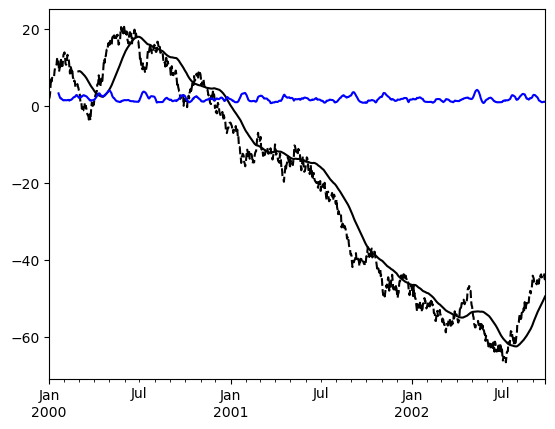

In [6]:
# some sample data
ts = pd.Series(np.random.randn(1000), index=pd.date_range('1/1/2000', periods=1000)).cumsum()

#plot the time series
ts.plot(style='k--')

# calculate a 60 day rolling mean and plot
ts.rolling(window=60,).mean().plot(style='k')

# add the 20 day rolling standard deviation:
ts.rolling(window=20).std().plot(style='b')


In [7]:
# Generate synthetic data
def generate_synthetic_data(n_datapoints=5000,locs_range=2.):
    weights = torch.ones(n_components) / n_components
    locs = torch.randn(n_components, n_latent) * locs_range
    scales = torch.ones(n_components, n_latent) * 0.5
    transform_matrix = 1.*torch.randn(n_latent, n_var)
    intercept = 4*torch.rand(n_components, n_var)-2.
    overall_intercept = 12*torch.rand(n_var)-6.
    data = []
    true_clusters=[]
    true_latent=[]
    for _ in range(n_datapoints):
        l = 8 + 2*torch.rand(1)
        z = torch.multinomial(weights, 1).item()
        true_clusters.append(z)
        latent = torch.normal(locs[z], scales[z])
        true_latent.append(latent)
        out_mu = latent @ transform_matrix + intercept[z] + overall_intercept
        total_counts = torch.tensor(25.0)
        logits = (torch.softmax(out_mu,dim=-1)*l.exp()).log() - torch.log(total_counts) 
        counts = dist.NegativeBinomial(total_counts, logits=logits).sample()
        data.append(counts)
    
    return torch.stack(data),{'latent':true_latent,'clusters':true_clusters,'weights':weights,'locs':locs,'scales':scales,'intercept':intercept}

# Generate synthetic data
data, true_params = generate_synthetic_data(n_datapoints=n_datapoints)

In [8]:
(data>0).sum(0)

tensor([31666,  5949, 31260,   692,  5741,     0,   634, 35273,    18, 14191,
           11,  4569,    17,   205,    38,   150, 12911,   820, 24052, 27993,
        28661, 40470, 38665,  3521, 22005, 52101, 25690,  1878, 47787,  5090,
        31607, 42061,    38,   111, 33575, 58022,  1035,    52, 27095, 11935,
         3536, 27598, 34908,  4252, 29151,    14, 12804,  1389,  3553,  4209,
         5238, 26281,  1601, 10166, 27128,   850, 15580,  1912,   401,     2,
        52233,   618, 17555, 20278,   706,  6991,   190,  4597,   119, 18982,
        24478,  3259, 19137,  2802,  1032,  2901, 21220,   182,  5200,   112,
        23674,   138,  1299,  1336,   643,  9513,  2182,  8190, 19459, 28250,
        12018, 36657,   191,  2083, 13746,   696,    13,  8764, 39599,    76,
         2436,     2,  8147, 21262,  1029, 43182,   969, 13090,  1229, 23684,
        28141, 50323, 39727, 31787, 13770,    82,  8637,    21, 24969,  6568,
        10487,    34, 36386,  2525,   796, 28518,  7943,  1589, 

Text(0.5, 1.0, 'distribution of count values')

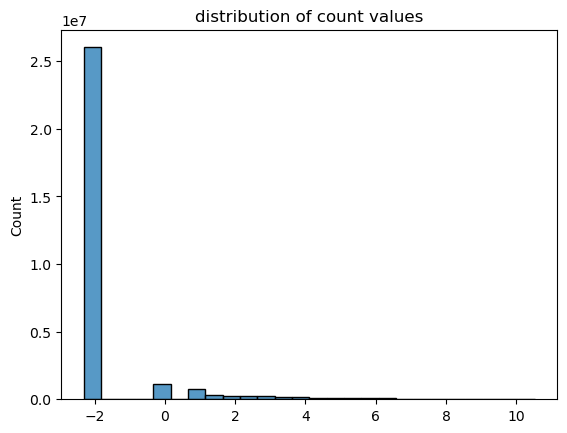

In [9]:
seaborn.histplot(np.log(data.flatten()+0.1))
plt.title('distribution of count values')

Text(0.5, 1.0, 'distribution of library sizes')

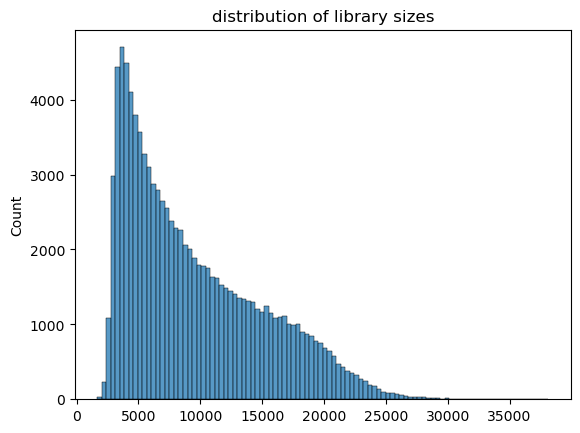

In [10]:

seaborn.histplot(data.sum(1).flatten(),bins=100)
plt.title('distribution of library sizes')

In [11]:
adata=anndata.AnnData(X=data.cpu().numpy(),obs=pd.DataFrame([str(x) for x in true_params['clusters']],columns=['true_clusters']))
adata.obsm['true_latents']=np.stack(true_params['latent'],axis=0)

/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [12]:
toy_model = ToyModel(n_latent = n_latent+5,n_var = n_var,n_components = n_components+5)
toy_model.to(device)

# SVI setup
adam_params = {"lr": 0.005}
optimizer = Adam(adam_params)
svi = SVI(toy_model.model, toy_model.guide, optimizer, loss=pyro.infer.TraceEnum_ELBO())

# Training loop
num_iterations = 10
losses = []

In [13]:
for i in tqdm.tqdm(range(num_iterations)):
    loss = 0
    for j in range(0, n_datapoints, batch_size):
        batch = data[j:j+batch_size]
        loss = svi.step(batch.int().to(device))
        losses.append(loss)
    print(f"Iteration {i} : Loss {loss}")

print("Training complete.")

 10%|█         | 1/10 [01:15<11:15, 75.04s/it]

Iteration 0 : Loss -0.6799577474594116


 20%|██        | 2/10 [02:26<09:45, 73.16s/it]

Iteration 1 : Loss -0.7211593985557556


 30%|███       | 3/10 [03:38<08:27, 72.56s/it]

...

Iteration 7 : Loss -0.8503099679946899


 90%|█████████ | 9/10 [10:40<01:10, 70.31s/it]

Iteration 8 : Loss -0.8607304096221924


100%|██████████| 10/10 [11:51<00:00, 71.10s/it]

Iteration 9 : Loss -0.8650183081626892
Training complete.


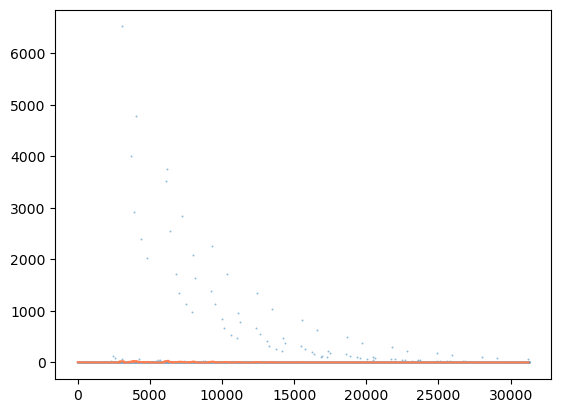

In [14]:
antipode.plotting.plot_loss(losses)

In [15]:
toy_model.eval()
latents=[]
clusters=[]
for j in range(0, n_datapoints, batch_size):
    batch = data[j:j+batch_size].to(device)
    latent=toy_model.encoder(batch)
    latents.append(latent[0].cpu().detach().numpy())
    component=toy_model.classifier(latent[0])
    clusters.append(component.cpu().detach().numpy())


In [16]:
adata.obsm['rec_latents']=np.concatenate(latents,axis=0)
adata.obs['rec_clusters']=np.concatenate(clusters,axis=0).argmax(-1)
adata.obs['rec_clusters']=adata.obs['rec_clusters'].astype(str)

In [17]:
adata.obsm['rec_mde']=scvi.model.utils.mde(adata.obsm['rec_latents'],init='random')
adata.obsm['true_mde']=scvi.model.utils.mde(adata.obsm['true_latents'],init='random')

INFO     Using cuda:0 for `pymde.preserve_neighbors`.                                                              


/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:191: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python3.11 /home/matthew.schmitz/Matthew/utils/miniforge3/e ...


INFO     Using cuda:0 for `pymde.preserve_neighbors`.                                                              


/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:191: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python3.11 /home/matthew.schmitz/Matthew/utils/miniforge3/e ...


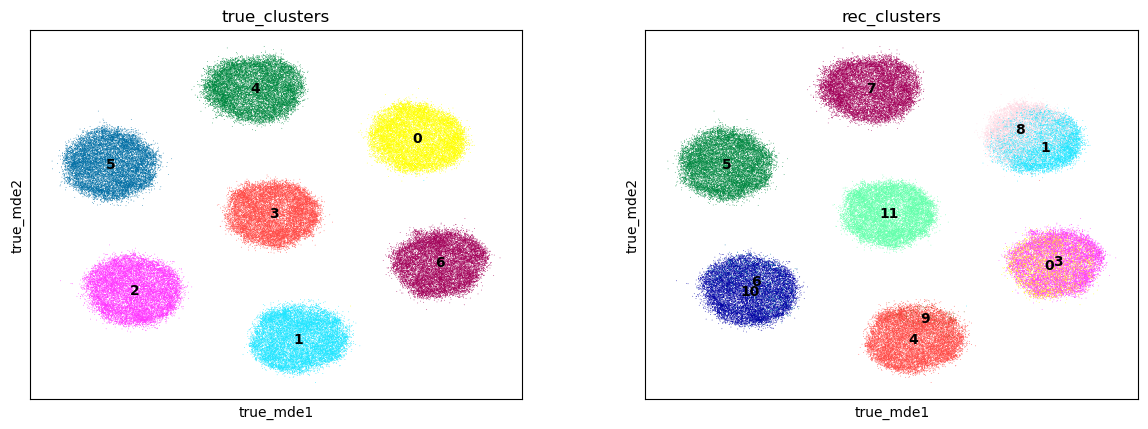

In [18]:
sc.pl.embedding(
    adata,
    basis='true_mde',
    color=['true_clusters','rec_clusters'],
    palette=sc.pl.palettes.godsnot_102,
    legend_loc='on data'
)


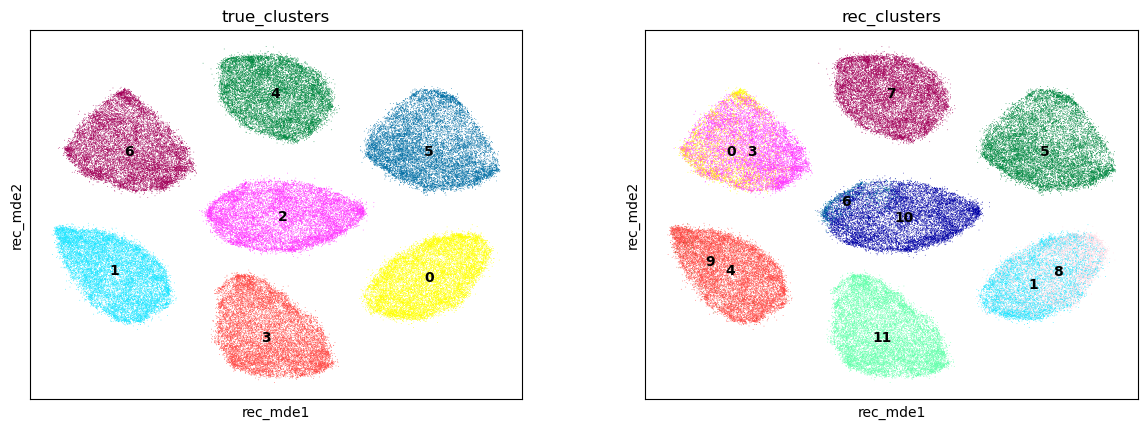

In [19]:
sc.pl.embedding(
    adata,
    basis='rec_mde',
    color=['true_clusters','rec_clusters'],
    palette=sc.pl.palettes.godsnot_102,
    legend_loc='on data'
)

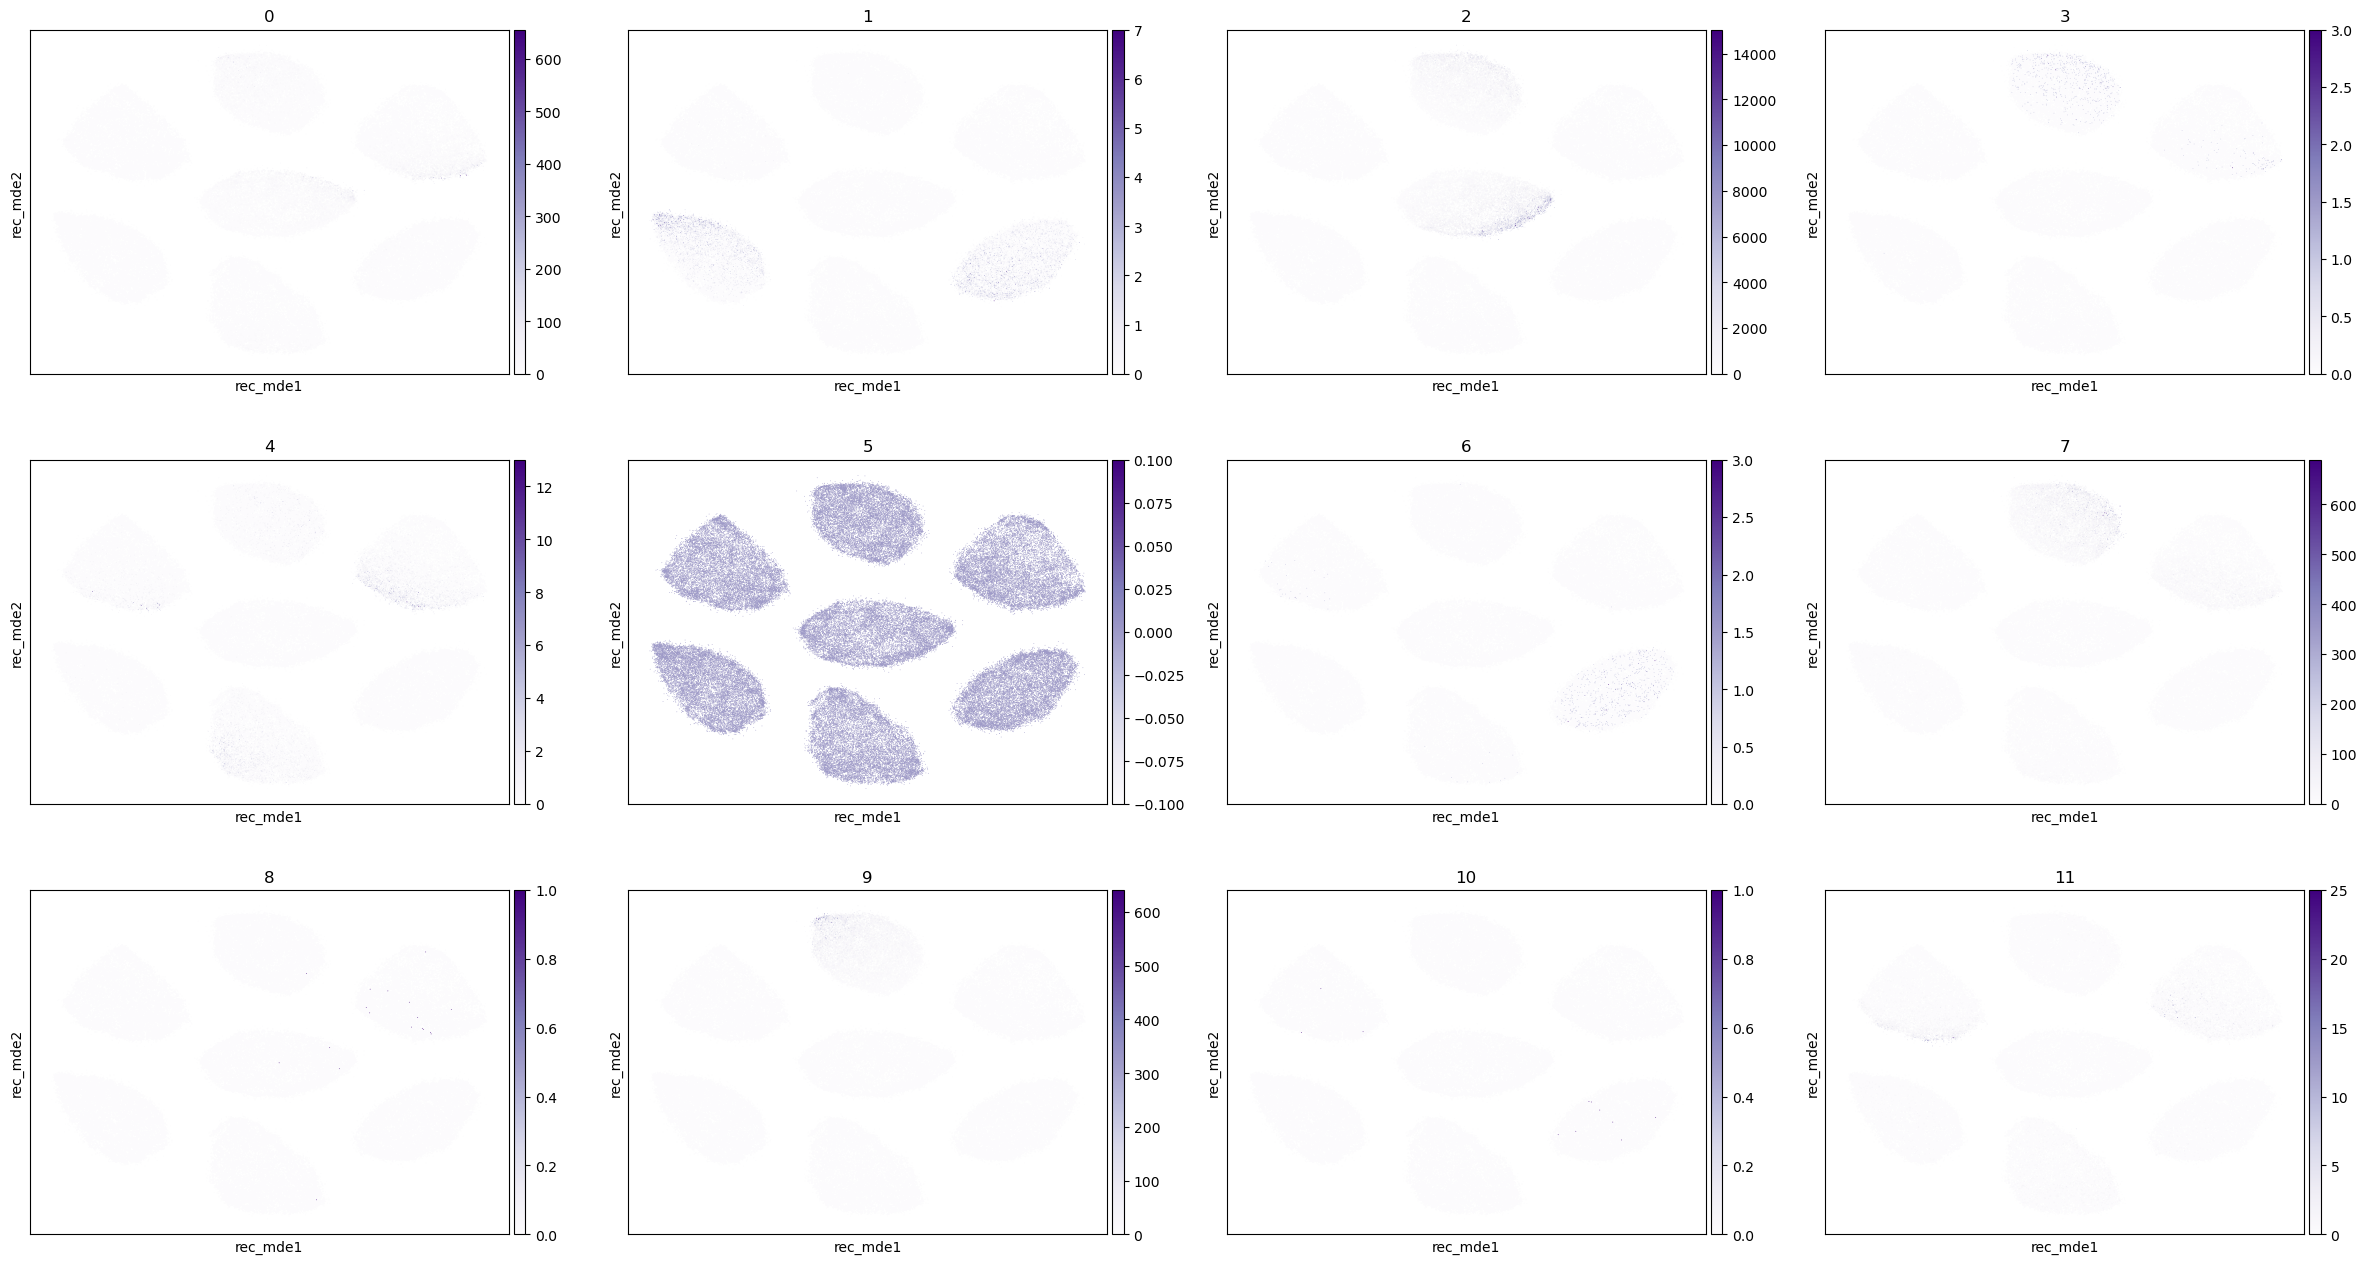

In [20]:
sc.pl.embedding(
    adata,
    basis='rec_mde',
    color=adata.var.index[0:12],
    cmap='Purples',
    legend_loc='on data'
)

In [21]:
out_locs = pyro.param('locs').detach().cpu().numpy()
out_transform_matrix = pyro.param('transform_matrix').detach().cpu().numpy()
out_intercept = pyro.param('intercept').detach().cpu().numpy()

# Compute the learned cluster means
learned_means = torch.nn.functional.log_softmax(torch.tensor(out_locs @ out_transform_matrix + out_intercept),dim=-1).numpy()
learned_means_clusters=[str(x) for x in range(learned_means.shape[0])]
#actual_means = true_params['locs'] @ true_params['transform_matrix'] + true_params['intercept']
actual_means = antipode.model_functions.group_aggr_anndata(adata,['rec_clusters'],normalize=True)
learned_means=learned_means[pd.Series(learned_means_clusters).isin(actual_means[1]['rec_clusters']),:]
actual_means=np.log(actual_means[0]+actual_means[0][actual_means[0]>0].min()*0.5)

100%|██████████| 11/11 [00:00<00:00, 46.75it/s]


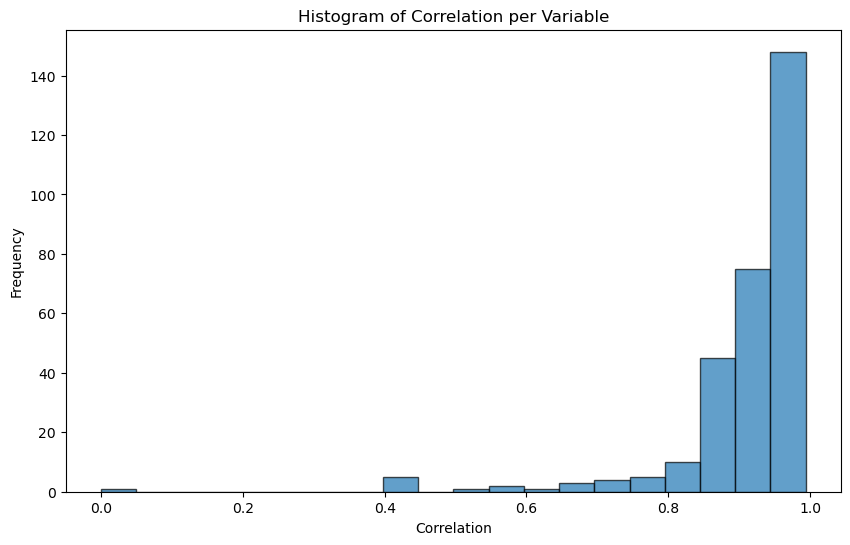

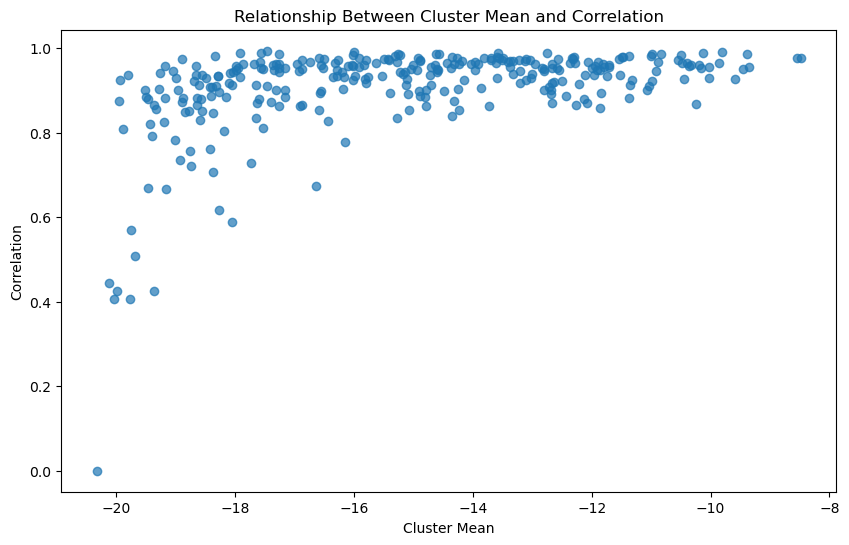

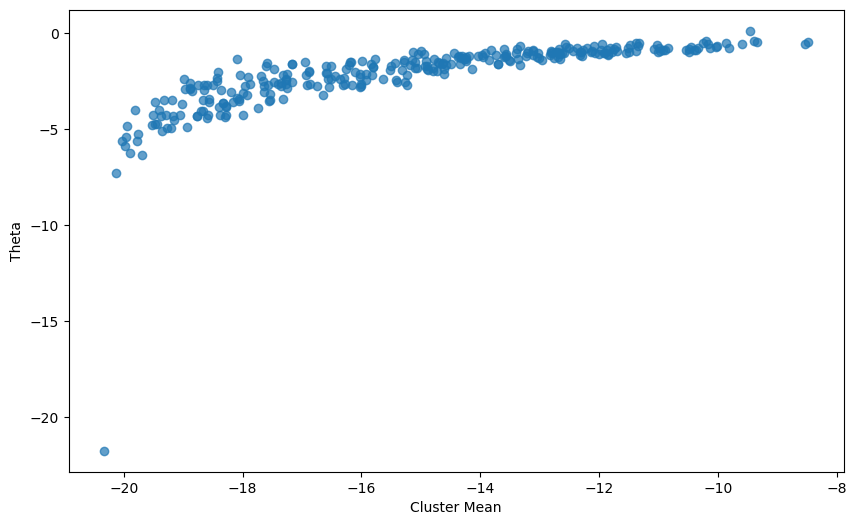

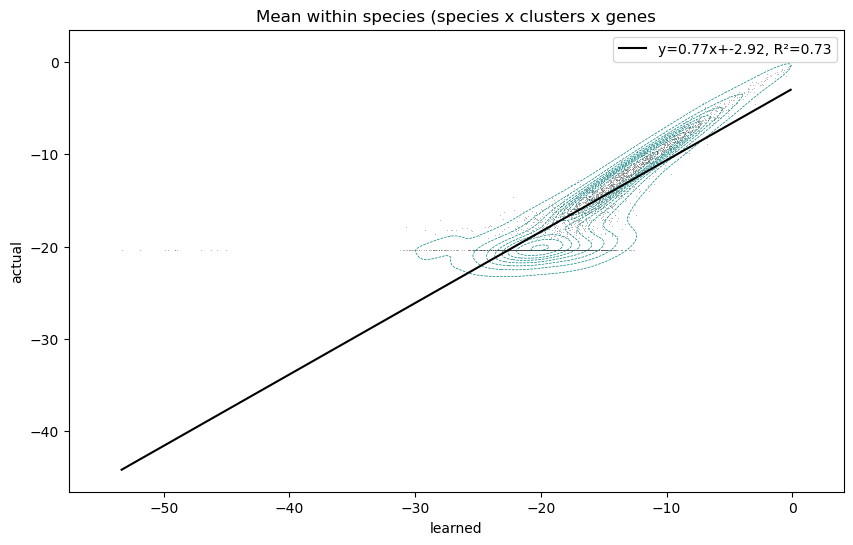

In [22]:
correlations = []
for i in range(toy_model.n_var):
    corr = np.corrcoef(actual_means[:, i], learned_means[:, i])[0, 1]
    correlations.append(corr)

# Plot a histogram of the correlations
plt.figure(figsize=(10, 6))
plt.hist(correlations, bins=20, edgecolor='k', alpha=0.7)
plt.xlabel('Correlation')
plt.ylabel('Frequency')
plt.title('Histogram of Correlation per Variable')
plt.show()

# Plot the relationship between the correlation and the cluster mean
plt.figure(figsize=(10, 6))
plt.scatter(actual_means.mean(axis=0), correlations, alpha=0.7)
plt.xlabel('Cluster Mean')
plt.ylabel('Correlation')
plt.title('Relationship Between Cluster Mean and Correlation')
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(actual_means.mean(axis=0), pyro.param('total_counts').log().cpu().detach().numpy(), alpha=0.7)
plt.xlabel('Cluster Mean')
plt.ylabel('Theta')
plt.show()


plt.figure(figsize=(10, 6))
x=learned_means.flatten()
y=actual_means.flatten()
seaborn.scatterplot(x=x,y=actual_means.flatten(),s=0.2,color='black')
seaborn.kdeplot(x=learned_means.flatten(),y=y,linestyles='--',color='teal', linewidths=0.5)
slope, intercept, r_value, p_value, std_err = scipy.stats.linregress(x,y)

# Plot the regression line
x_values = np.linspace(np.min(x), np.max(x), 100)
plt.plot(x_values, slope * x_values + intercept, color='black', label=f'y={slope:.2f}x+{intercept:.2f}, R²={r_value**2:.2f}')
plt.title('Mean within species (species x clusters x genes')
# Add legend
plt.legend()
plt.ylabel('actual')
plt.xlabel('learned')
plt.show()


Text(0.5, 1.0, 'NegativeBinomial(r=5,p=expit(x)) log probability')

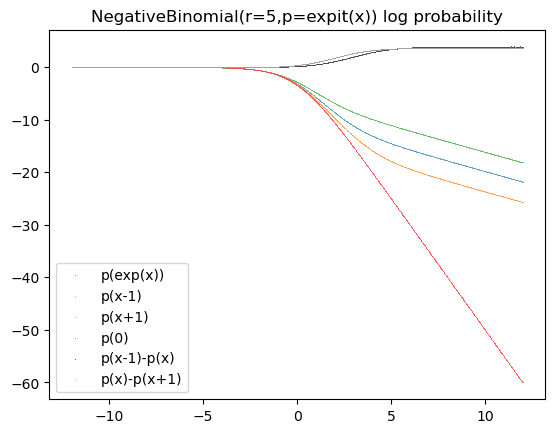

In [23]:
total_counts=5*torch.ones(1)
mus=torch.linspace(-12., 12.,1000).unsqueeze(0)
log_probs=dist.NegativeBinomial(logits=mus,total_count=total_counts,validate_args=False).log_prob(torch.cat([mus-total_counts.log(),mus-1-total_counts.log(),mus+1-total_counts.log(),mus.new_zeros(mus.shape)-100],dim=0).exp())
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[0].numpy().flatten(),s=0.5,label='p(exp(x))')
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[1].numpy().flatten(),s=0.5,label='p(x-1)')
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[2].numpy().flatten(),s=0.5,label='p(x+1)')
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[3].numpy().flatten(),s=0.5,c='red',label='p(0)')
seaborn.scatterplot(x=mus.numpy().flatten(),y=(log_probs[0]-log_probs[1]).numpy().flatten(),s=0.5,c='black',label='p(x-1)-p(x)')
seaborn.scatterplot(x=mus.numpy().flatten(),y=(log_probs[2]-log_probs[0]).numpy().flatten(),s=0.5,c='grey',label='p(x)-p(x+1)')
plt.title('NegativeBinomial(r=5,p=expit(x)) log probability')

In [24]:
import h5py
import anndata
with h5py.File('/allen/programs/celltypes/workgroups/rnaseqanalysis/dyuan/HMBA_analysis/data_files/h5ad/HMBA_allCells_10161HVGs_allMeta.h5ad') as f:
    obs = anndata.experimental.read_elem(f['obs'])

In [25]:
obs = pd.read_csv('/allen/programs/celltypes/workgroups/rnaseqanalysis/dyuan/HMBA_analysis/data_files/original_countMatrix/M/HMBA_Human_M_metadata.csv')

In [26]:
obs

,Unnamed: 0,sample_id,bc,ar_id,umi.counts,barcodes,gene.counts.0,gene.counts.1,gene.counts.4,gene.counts.8,...,GEX_Reads_mapped_to_genome,GEX_Reads_with_TSO,GEX_Sequenced_read_pairs,GEX_Total_genes_detected,GEX_Valid_UMIs,GEX_Valid_barcodes,arrow_file,bc_gex_match,doublet_score,exclude2
0,1,AAACAGCCAAGCCAGA-L8XR_230824_01_D03-1295697299,AAACAGCCAAGCCAGA,1295697299,7344,AAACAGCCAAGCCAGA,2681,1194,334,128,...,0.9635,0.2503,1124818417,32944,0.9977,0.9365,1826_B07_MTX-12006_human.arrow,1826_B07_MTX-12006_human#AAACAGCCAAGCCAGA-1,0.061538,No
1,2,AAACAGCCAGCAAATA-L8XR_230824_01_D03-1295697299,AAACAGCCAGCAAATA,1295697299,18726,AAACAGCCAGCAAATA,5751,2952,867,343,...,0.9635,0.2503,1124818417,32944,0.9977,0.9365,1826_B07_MTX-12006_human.arrow,1826_B07_MTX-12006_human#AAACAGCCAGCAAATA-1,0.242424,No
2,3,AAACAGCCATGTTGTG-L8XR_230824_01_D03-1295697299,AAACAGCCATGTTGTG,1295697299,988,AAACAGCCATGTTGTG,705,136,6,1,...,0.9635,0.2503,1124818417,32944,0.9977,0.9365,1826_B07_MTX-12006_human.arrow,1826_B07_MTX-12006_human#AAACAGCCATGTTGTG-1,0.000000,YES
3,4,AAACATGCAAGCCAGA-L8XR_230824_01_D03-1295697299,AAACATGCAAGCCAGA,1295697299,2377,AAACATGCAAGCCAGA,1474,391,50,13,...,0.9635,0.2503,1124818417,32944,0.9977,0.9365,1826_B07_MTX-12006_human.arrow,1826_B07_MTX-12006_human#AAACATGCAAGCCAGA-1,0.015385,No
4,5,AAACATGCAATTATGC-L8XR_230824_01_D03-1295697299,AAACATGCAATTATGC,1295697299,8675,AAACATGCAATTATGC,3295,1486,385,143,...,0.9635,0.2503,1124818417,32944,0.9977,0.9365,1826_B07_MTX-12006_human.arrow,1826_B07_MTX-12006_human#AAACATGCAATTATGC-1,0.030769,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
217862,217863,TTTGTGGCAAATATCC-L8XR_231005_01_C02-1305021516,TTTGTGGCAAATATCC,1305021516,55754,TTTGTGGCAAATATCC,9534,6194,2773,1366,...,0.9560,0.1521,692915587,32893,0.9980,0.9107,1887_B04_MTX-12011_human.arrow,1887_B04_MTX-12011_human#TTTGTGGCAAATATCC-1,0.500000,YES
217863,217864,TTTGTGTTCAGCAAAG-L8XR_231005_01_C02-1305021516,TTTGTGTTCAGCAAAG,1305021516,17206,TTTGTGTTCAGCAAAG,5440,2655,757,332,...,0.9560,0.1521,692915587,32893,0.9980,0.9107,1887_B04_MTX-12011_human.arrow,1887_B04_MTX-12011_human#TTTGTGTTCAGCAAAG-1,0.050000,No
217864,217865,TTTGTGTTCATTAGTG-L8XR_231005_01_C02-1305021516,TTTGTGTTCATTAGTG,1305021516,39113,TTTGTGTTCATTAGTG,7625,4703,2029,981,...,0.9560,0.1521,692915587,32893,0.9980,0.9107,1887_B04_MTX-12011_human.arrow,1887_B04_MTX-12011_human#TTTGTGTTCATTAGTG-1,0.150000,No
217865,217866,TTTGTGTTCCCGTTTA-L8XR_231005_01_C02-1305021516,TTTGTGTTCCCGTTTA,1305021516,4327,TTTGTGTTCCCGTTTA,2065,794,120,41,...,0.9560,0.1521,692915587,32893,0.9980,0.9107,1887_B04_MTX-12011_human.arrow,1887_B04_MTX-12011_human#TTTGTGTTCCCGTTTA-1,0.000000,No


In [27]:
list(obs.columns)

['Unnamed: 0',
 'sample_id',
 'bc',
 'ar_id',
 'umi.counts',
 'barcodes',
 'gene.counts.0',
 'gene.counts.1',
 'gene.counts.4',
 'gene.counts.8',
 'gene.counts.16',
 'gene.counts.32',
 'gene.counts.64',
 'exclude',
 'exp_component_name',
 'exp_component_vendor_name',
 'batch',
 'batch_vendor_name',
 'tube',
 'tube_internal_name',
 'tube_contents_nm',
 'tube_contents_nm_from_vendor',
 'tube_avg_size_bp',
 'tube_input_fmol',
 'r1_index',
 'r2_index',
 'index_sequence_pair',
 'organism',
 'reference_id',
 'facs_container',
 'sample_name',
 'patched_cell_container',
 'cell_name',
 'cell_id',
 'studies',
 'hemisphere_name',
 'sample_quantity_count',
 'expc_cell_capture',
 'sample_quantity_pg',
 'donor_name',
 'external_donor_name',
 'age',
 'species',
 'sex',
 'control',
 'cell_prep_type',
 'full_genotype',
 'facs_population_plan',
 'cre_line',
 'reporter',
 'injection_roi',
 'injection_method',
 'injection_materials',
 'injection_type',
 'roi',
 'patchseq_roi',
 'medical_conditions',
 'sli

In [28]:
obs['ar_id']

0         1295697299
1         1295697299
2         1295697299
3         1295697299
4         1295697299
             ...    
217862    1305021516
217863    1305021516
217864    1305021516
217865    1305021516
217866    1305021516
Name: ar_id, Length: 217867, dtype: int64

In [29]:
list(obs['ar_directory'].unique())

['/allen/programs/celltypes/production/mousecelltypes/prod1/ARC_Analysis_Run_1295697299/',
 '/allen/programs/celltypes/production/mousecelltypes/prod1/ARC_Analysis_Run_1295697298/',
 '/allen/programs/celltypes/production/mousecelltypes/prod1/ARC_Analysis_Run_1297375561/',
 '/allen/programs/celltypes/production/mousecelltypes/prod1/ARC_Analysis_Run_1297375558/',
 '/allen/programs/celltypes/production/mousecelltypes/prod1/ARC_Analysis_Run_1297375559/',
 '/allen/programs/celltypes/production/mousecelltypes/prod1/ARC_Analysis_Run_1297375560/',
 '/allen/programs/celltypes/production/mousecelltypes/prod7/ARC_Analysis_Run_1300545232/',
 '/allen/programs/celltypes/production/mousecelltypes/prod7/ARC_Analysis_Run_1300545234/',
 '/allen/programs/celltypes/production/mousecelltypes/prod2/ARC_Analysis_Run_1301618330/',
 '/allen/programs/celltypes/production/mousecelltypes/prod2/ARC_Analysis_Run_1301618325/',
 '/allen/programs/celltypes/production/mousecelltypes/prod2/ARC_Analysis_Run_1301618326/',